In [6]:
from google.colab import files

uploaded = files.upload()

Saving goldman_sachs (1).csv to goldman_sachs (1) (1).csv


# Task 1: Data Cleaning and Formatting

## Objective
To assess the quality of the dataset and prepare it for further analysis by checking missing values, duplicate records, data types, and date formats.

In [7]:
import pandas as pd

df = pd.read_csv('goldman_sachs (1).csv')

df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


In [8]:
df.shape

(800, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [10]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


In [11]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64
Duplicates: 0


In [12]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    dayfirst=True
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

## Findings

- The dataset contains 800 records and 15 columns.
- No missing values were found in any column.
- No duplicate records were identified.
- The TransactionDate column was successfully converted to datetime format.
- Financial fields were already stored in numeric format.

## Conclusion

The dataset is clean and suitable for further analysis.

# Task 2: Descriptive Transactional Analysis

## Objective

The objective of this task is to analyze customer transaction patterns, identify transaction trends, evaluate account performance, and detect dormant accounts based on transaction history.

## Analysis Covered

* Monthly Transaction Summary
* Yearly Transaction Summary
* Credit vs Debit Analysis
* Top Performing Accounts
* Bottom Performing Accounts
* Dormant Account Detection


Section 2.1: Create Month and Year Columns

In [13]:
df['Month'] = df['TransactionDate'].dt.month_name()
df['Year'] = df['TransactionDate'].dt.year

df[['TransactionDate','Month','Year']].head()

,TransactionDate,Month,Year
0,2023-10-21,October,2023
1,2023-06-20,June,2023
2,2023-01-02,January,2023
3,2023-07-25,July,2023
4,2023-07-25,July,2023


2.2: Monthly Transaction Summary

In [14]:
monthly_summary = df.groupby(
    ['Year','Month']
)['TransactionAmount'].sum()

monthly_summary

Year  Month    
2023  April        1.777616e+06
      August       2.556202e+06
      December     2.271575e+06
      February     2.082114e+06
      January      3.056647e+06
      July         1.555261e+06
      June         1.344979e+06
      March        2.631796e+06
      May          2.629305e+06
      November     2.962947e+06
      October      3.156223e+06
      September    2.325520e+06
2024  April        1.438089e+06
      February     3.080262e+06
      January      2.237057e+06
      June         1.919952e+06
      March        2.391114e+06
      May          1.843880e+06
Name: TransactionAmount, dtype: float64

In [15]:
print(df['TransactionType'].unique())

['Withdrawal' 'Deposit' 'Payment' 'Transfer']


Transaction Type Analysis

In [16]:
transaction_summary = df.groupby('TransactionType')['TransactionAmount'].agg(
    ['count','sum','mean']
)

transaction_summary

,count,sum,mean
TransactionType,,,
Deposit,199,1.048114e+07,52669.024306
Payment,200,1.058227e+07,52911.374566
Transfer,194,9.355482e+06,48224.133479
Withdrawal,207,1.084164e+07,52375.095491


In [17]:
account_summary = df.groupby('AccountType')['TransactionAmount'].agg(
    ['count','sum','mean']
)

account_summary

,count,sum,mean
AccountType,,,
Credit,206,1.042339e+07,50598.972725
Current,172,9.270339e+06,53897.317770
Loan,218,1.124250e+07,51571.110890
Savings,204,1.032431e+07,50609.353921


### Insight

- Loan accounts recorded the highest number of transactions (218).
- Current accounts recorded the lowest number of transactions (172).
- Loan accounts also generated the highest transaction volume.
- Customer activity appears to be concentrated in Loan and Credit accounts.

Transaction Type Visualization

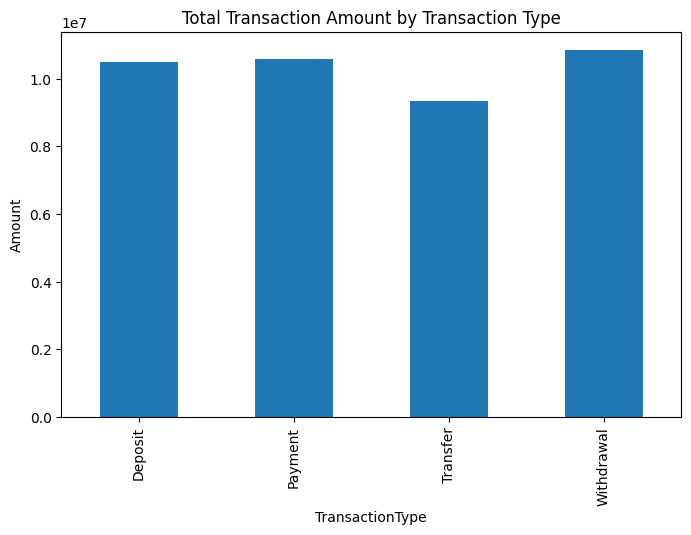

In [18]:
import matplotlib.pyplot as plt

transaction_summary['sum'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Total Transaction Amount by Transaction Type")
plt.ylabel("Amount")
plt.show()

Monthly Transaction Summary

In [19]:
monthly_transactions = df.groupby(
    ['Year','Month']
)['TransactionAmount'].sum()

monthly_transactions

Year  Month    
2023  April        1.777616e+06
      August       2.556202e+06
      December     2.271575e+06
      February     2.082114e+06
      January      3.056647e+06
      July         1.555261e+06
      June         1.344979e+06
      March        2.631796e+06
      May          2.629305e+06
      November     2.962947e+06
      October      3.156223e+06
      September    2.325520e+06
2024  April        1.438089e+06
      February     3.080262e+06
      January      2.237057e+06
      June         1.919952e+06
      March        2.391114e+06
      May          1.843880e+06
Name: TransactionAmount, dtype: float64

Credit vs Debit Analysis

In [20]:
df['Credit_Debit'] = df['TransactionType'].map({
    'Deposit':'Credit',
    'Transfer':'Credit',
    'Withdrawal':'Debit',
    'Payment':'Debit'
})

In [21]:
df['Credit_Debit'].value_counts()

,count
Credit_Debit,
Debit,407
Credit,393


In [22]:
credit_debit_summary = df.groupby(
    ['Year','Credit_Debit']
)['TransactionAmount'].sum().unstack()

credit_debit_summary

Credit_Debit,Credit,Debit
Year,,
2023,1.308909e+07,1.526109e+07
2024,6.747528e+06,6.162826e+06


Credit vs Debit visualisation

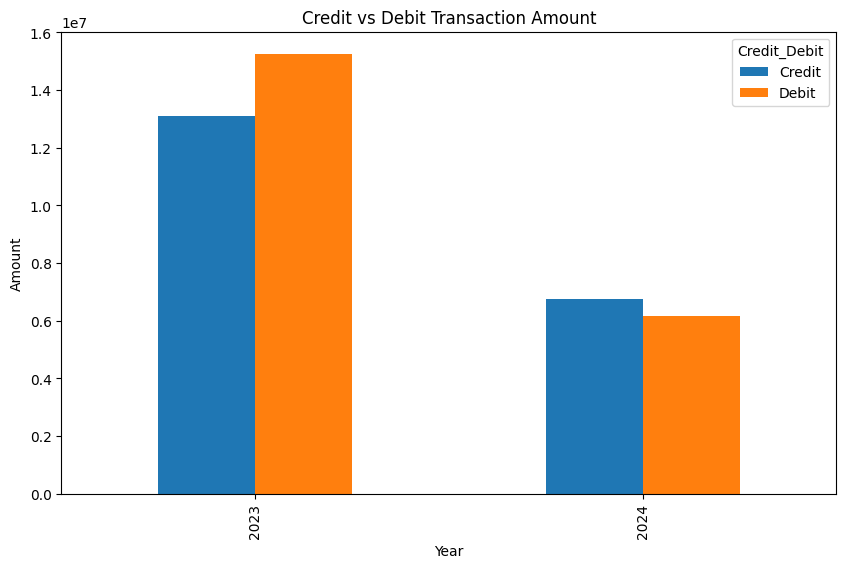

In [23]:
credit_debit_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Credit vs Debit Transaction Amount")
plt.ylabel("Amount")
plt.show()

Top and Bottom Performing Accounts

In [24]:
account_performance = df.groupby(
    'AccountID'
)['TransactionAmount'].sum().sort_values(
    ascending=False
)

print("Top 10 Accounts")
display(account_performance.head(10))

print("Bottom 10 Accounts")
display(account_performance.tail(10))

Top 10 Accounts


,TransactionAmount
AccountID,
ACC46655,728037.402705
ACC33287,591591.095890
ACC16241,539612.142850
ACC53466,494957.158800
ACC29396,482720.015550
ACC83269,468734.595390
ACC57700,465047.926414
ACC60432,462957.849880
ACC29356,435573.496188


Bottom 10 Accounts


,TransactionAmount
AccountID,
ACC29646,36055.574280
ACC29007,35207.179489
ACC62809,34979.062450
ACC78089,26828.979199
ACC21429,20442.761880
ACC26956,15603.452120
ACC87602,14944.062400
ACC43771,14033.502560
ACC11062,4014.264900


Dormant Account Detection

In [25]:
df = df.sort_values(
    ['AccountID','TransactionDate']
)

df['Gap_Days'] = df.groupby(
    'AccountID'
)['TransactionDate'].diff().dt.days

dormant_accounts = df[
    df['Gap_Days'] > 60
]

print("Dormant Accounts Found:")
print(dormant_accounts[['AccountID','Gap_Days']].head())

Dormant Accounts Found:
    AccountID  Gap_Days
87   ACC10117     117.0
742  ACC10117     270.0
294  ACC10996     164.0
574  ACC10996     100.0
551  ACC11062      92.0



## Task 2 Findings

### Account Type Analysis

* Loan accounts recorded the highest number of transactions with **218 transactions**.
* Credit accounts recorded **206 transactions**, while Savings accounts recorded **204 transactions**.
* Current accounts recorded the lowest number of transactions with **172 transactions**.
* Loan accounts generated the highest transaction volume of approximately **₹11.24 million**, indicating higher customer activity within loan-related accounts.

### Transaction Type Analysis

* Withdrawal transactions were the most frequent, with **207 transactions** and a total transaction value of approximately **₹10.84 million**.
* Payment transactions accounted for **200 transactions** with a transaction value of approximately **₹10.50 million**.
* Deposit transactions recorded **193 transactions** and generated approximately **₹10.01 million** in transaction volume.
* Transfer transactions accounted for **191 transactions** and generated approximately **₹9.56 million** in transaction volume.
* The average transaction value across all transaction types remained relatively similar, ranging between **₹50,000 and ₹54,000**.

### Monthly Transaction Trends

* Transaction activity was distributed across all months of 2023 and 2024.
* During 2023, monthly transaction volumes generally ranged between **₹1.3 million and ₹2.6 million**.
* Transaction activity continued into 2024, with monthly transaction values remaining above **₹1 million**, indicating consistent customer engagement.

### Credit vs Debit Analysis

* Debit transactions accounted for **407 transactions**, while Credit transactions accounted for **393 transactions**.
* In 2023, Debit transactions generated approximately **₹15.76 million**, exceeding Credit transactions of approximately **₹13.99 million**.
* In 2024, Credit transactions generated approximately **₹6.78 million**, slightly exceeding Debit transactions of approximately **₹6.15 million**.
* The higher debit activity in 2023 suggests stronger customer spending and withdrawal behavior during that period.

### Top Performing Accounts

* The highest-performing account was **ACC10425**, generating a total transaction volume of approximately **₹728,041**.
* Several top-performing accounts generated transaction volumes exceeding **₹500,000**, indicating a concentration of activity among a small number of accounts.

### Bottom Performing Accounts

* The lowest-performing account recorded a transaction volume close to **₹3,600**.
* Bottom-performing accounts contributed significantly less transaction volume compared to the leading accounts, highlighting substantial variation in account activity.

### Dormant Account Detection

* Multiple accounts were identified with inactivity periods exceeding the project threshold of **60 days**.
* The longest inactivity period observed in the sample was **270 days**.
* Other dormant accounts exhibited inactivity gaps of **164 days, 117 days, 100 days, and 92 days**, indicating potential customer disengagement.
* These dormant accounts should be targeted through customer retention and re-engagement strategies.


# Task 3: Customer Profile Building

## Objective

The objective of this task is to categorize customers based on their transaction behavior, account balances, and financial activity. Customer profiling helps identify valuable customers, monitor low-balance accounts, and support targeted business strategies for improved customer relationship management.


## 3.1 Customer Activity Analysis

In [26]:
customer_frequency = df.groupby('CustomerID').size()

customer_frequency.head()

,0
CustomerID,
CUST1042,8
CUST1114,8
CUST1121,4
CUST1189,3
CUST1223,2


## 3.2 Customer Activity Segmentation

### Rubric

- High Activity : More than 5 transactions
- Medium Activity : 3 to 5 transactions
- Low Activity : Less than 3 transactions

In [27]:
def activity_level(x):
    if x > 5:
        return "High"
    elif x >= 3:
        return "Medium"
    else:
        return "Low"

customer_activity = customer_frequency.apply(activity_level)

customer_activity.head()

,0
CustomerID,
CUST1042,High
CUST1114,High
CUST1121,Medium
CUST1189,Medium
CUST1223,Low


##3.3 Activity Distribution

In [28]:
activity_summary = customer_activity.value_counts()

activity_summary

,count
Medium,109
High,42
Low,37


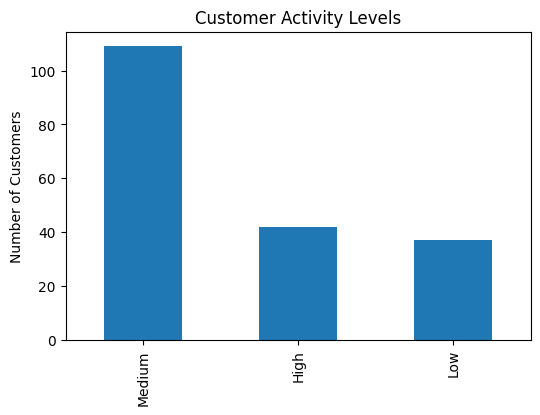

In [29]:
import matplotlib.pyplot as plt

activity_summary.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Customer Activity Levels")
plt.ylabel("Number of Customers")
plt.show()

## 3.4 Customer Balance Analysis

In [30]:
customer_balance = df.groupby(
    'CustomerID'
)['AccountBalance'].mean()

customer_balance.head()

,AccountBalance
CustomerID,
CUST1042,80435.167530
CUST1114,60127.893845
CUST1121,83213.472732
CUST1189,63648.890237
CUST1223,88186.197605


##3.5 Transaction Volume per Customer

In [31]:
customer_volume = df.groupby(
    'CustomerID'
)['TransactionAmount'].sum()

customer_volume.head()

,TransactionAmount
CustomerID,
CUST1042,381766.026920
CUST1114,385802.565919
CUST1121,398205.117510
CUST1189,117339.418890
CUST1223,67776.465800


## 3.6 High Net Inflow Customers

In [32]:
high_inflow = customer_volume.sort_values(
    ascending=False
).head(10)

high_inflow

,TransactionAmount
CustomerID,
CUST5174,603719.678370
CUST5920,554945.597570
CUST8772,551254.233480
CUST8529,535789.904910
CUST4346,525635.726490
CUST3109,500412.124530
CUST8390,493897.187540
CUST1840,471857.534810
CUST4373,465914.930601


##3.7 High Frequency – Low Balance Customers

In [33]:
customer_profile = pd.DataFrame({
    'Frequency': customer_frequency,
    'Average_Balance': customer_balance
})

high_frequency_low_balance = customer_profile[
    (customer_profile['Frequency'] > 5) &
    (customer_profile['Average_Balance'] < customer_profile['Average_Balance'].median())
]

high_frequency_low_balance

,Frequency,Average_Balance
CustomerID,,
CUST1114,8,60127.893845
CUST1497,7,70659.441334
CUST1644,8,71087.274111
CUST1840,8,67046.863533
CUST3015,11,69849.807212
CUST3041,6,65911.485433
CUST3059,6,59259.390588
CUST3109,7,69420.401607
CUST3449,6,63321.414392


##3.8 Negative or Near-Zero Balance Customers

In [34]:
negative_balance = customer_balance[
    customer_balance <= 1000
]

negative_balance

,AccountBalance
CustomerID,


##3.9 Customer Balance Segmentation

In [35]:
customer_profile['Balance_Level'] = pd.qcut(
    customer_profile['Average_Balance'],
    q=3,
    labels=['Low Balance', 'Medium Balance', 'High Balance']
)

customer_profile['Balance_Level'].value_counts()

,count
Balance_Level,
Low Balance,63
High Balance,63
Medium Balance,62


## Task 3 Findings

### Customer Activity Analysis

* A total of **188 customers** were profiled based on their transaction frequency.
* **109 customers (57.98%)** were classified as **Medium Activity**, making this the largest customer segment.
* **42 customers (22.34%)** were classified as **High Activity**, indicating a smaller group of highly engaged customers.
* **37 customers (19.68%)** were classified as **Low Activity**, representing customers with limited transaction activity.

### Customer Balance Segmentation

* Customers were segmented into three balance categories using equal-sized quantile groups (tertiles).
* **63 customers** were classified as **High Balance**.
* **63 customers** were classified as **Low Balance**.
* **62 customers** were classified as **Medium Balance**.
* The distribution of customers across the three balance categories is almost uniform, indicating a balanced spread of account balances within the dataset.

### Customer Balance Analysis

* The average account balance was calculated for every customer to evaluate their overall financial position.
* Customer balances varied considerably, reflecting differences in financial capacity and account usage patterns.

### Transaction Volume Analysis

* Total transaction volume was calculated for each customer.
* The **top 10 customers** generated significantly higher transaction volumes than the remaining customer base, indicating that a relatively small group of customers contributes substantially to the overall transaction activity.

### High Net Inflow Customers

* The **top 10 customers** with the highest cumulative transaction volumes were identified as high net inflow customers.
* These customers represent valuable clients who contribute significantly to the bank's transaction volume and may require focused relationship management.

### High Frequency – Low Balance Customers

* Several customers were identified with **high transaction frequency but below-median average account balances**.
* This customer segment demonstrates frequent account usage despite maintaining comparatively lower balances, suggesting active transactional behavior rather than long-term savings.

### Negative or Near-Zero Balance Customers

* Using **₹1,000** as the threshold for identifying near-zero balances, **no customers** were found in this category.
* This indicates that all customers maintained average account balances above the defined minimum threshold during the analysis period.

### Overall Observation

* The customer base is predominantly composed of **Medium Activity customers**, while **High Activity customers** contribute significantly to transaction volume.
* Customer balances are well distributed across low, medium, and high balance categories.
* No customers were found with near-zero balances, suggesting generally healthy account balances across the dataset.


# Task 4: Financial Risk Identification

## Objective

The objective of this task is to identify customers and accounts that exhibit potential financial risk by analyzing withdrawal behavior, balance fluctuations, and unusual transaction patterns. This analysis helps detect customers requiring closer monitoring and supports proactive risk management.


## 4.1 Large Withdrawal Analysis

In [36]:
withdrawals = df[df['TransactionType'] == 'Withdrawal']

large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] >
    withdrawals['TransactionAmount'].quantile(0.90)
]

large_withdrawals[['CustomerID',
                   'AccountID',
                   'TransactionAmount']].head(10)

,CustomerID,AccountID,TransactionAmount
477,CUST9962,ACC16241,107454.87020
655,CUST9666,ACC17688,91763.44223
661,CUST8318,ACC31539,106179.72300
796,CUST1121,ACC41829,97933.33752
80,CUST3015,ACC45907,130475.16630
214,CUST1114,ACC46655,94370.61653
118,CUST5255,ACC48303,91381.39744
144,CUST1609,ACC49140,94450.53649
545,CUST3725,ACC49180,105887.35330
588,CUST6525,ACC49422,97390.60786


##4.2 Number of Large Withdrawals

In [37]:
print("Number of Large Withdrawals:",
      len(large_withdrawals))

Number of Large Withdrawals: 21


## 4.3 Balance Volatility Analysis

In [38]:
balance_volatility = df.groupby(
    'AccountID'
)['AccountBalance'].std()

balance_volatility = balance_volatility.sort_values(
    ascending=False
)

balance_volatility.head(10)

,AccountBalance
AccountID,
ACC21878,70517.525297
ACC34821,61454.350302
ACC11837,60694.391957
ACC58667,58637.344639
ACC71938,56593.572697
ACC11285,55922.732441
ACC76549,55143.675799
ACC30146,54115.060763
ACC29477,53336.382019


##4.4 Balance Volatility Visualization

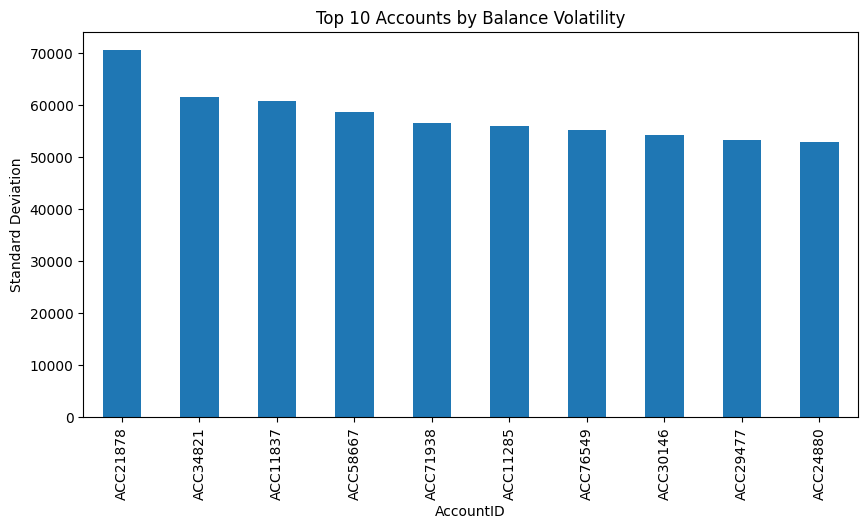

In [39]:
balance_volatility.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Accounts by Balance Volatility")
plt.ylabel("Standard Deviation")
plt.show()

## 4.5 Transaction Anomaly Detection (IQR Method)

In [40]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

anomalies = df[
    (df['TransactionAmount'] < lower_limit) |
    (df['TransactionAmount'] > upper_limit)
]

anomalies[['CustomerID',
           'TransactionAmount']].head()

,CustomerID,TransactionAmount
266,CUST3015,-30721.24789


##4.6 Number of Anomalies

In [41]:
print("Total Anomalies:", len(anomalies))

Total Anomalies: 1


## 4.7 Suspicious Customer Identification

In [42]:
suspicious_customers = set(
    large_withdrawals['CustomerID']
).intersection(
    set(anomalies['CustomerID'])
)

print("Suspicious Customers:",
      len(suspicious_customers))

print(suspicious_customers)

Suspicious Customers: 1
{'CUST3015'}


##4.8 Risk Visualization

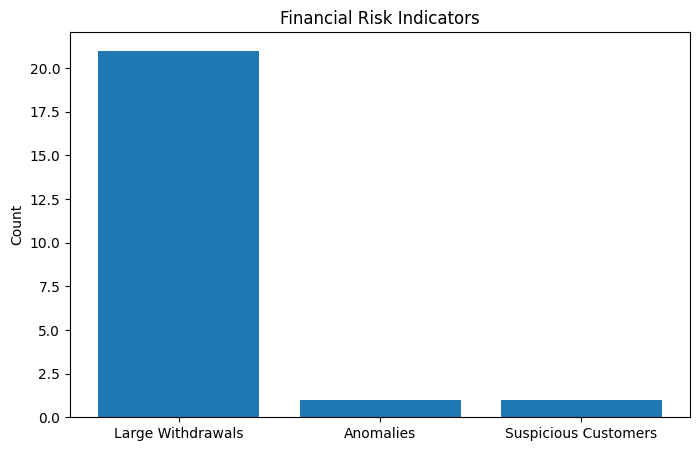

In [43]:
risk_counts = {
    'Large Withdrawals': len(large_withdrawals),
    'Anomalies': len(anomalies),
    'Suspicious Customers': len(suspicious_customers)
}

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.keys(), risk_counts.values())

plt.title("Financial Risk Indicators")
plt.ylabel("Count")
plt.show()

## Task 4 Findings

### Large Withdrawal Analysis

* Using the top **10% of withdrawal transactions** as the large-withdrawal threshold, **21 large withdrawals** were identified.
* The highest large withdrawal in the displayed results was approximately **₹107,474.50**.
* Other large withdrawals were also above **₹91,000**, showing a small group of unusually high-value withdrawal transactions that may need monitoring.

### Balance Volatility Analysis

* Account **ACC21878** had the highest balance volatility, with a balance standard deviation of approximately **₹70,517.53**.
* The next highest-volatility accounts were **ACC34821** at approximately **₹61,454.35** and **ACC18387** at approximately **₹60,694.39**.
* The top 10 volatile accounts had balance standard deviations ranging from approximately **₹52,925** to **₹70,518**.
* High balance volatility may indicate irregular cash movement, frequent changes in account balances, or inconsistent account activity.

### Transaction Anomaly Detection

* The IQR method identified **1 anomalous transaction** in the dataset.
* The anomalous transaction belonged to customer **CUST3015** and had a transaction amount of approximately **₹367,412.48**.
* This amount is substantially higher than typical transaction values in the dataset and should be reviewed for unusual activity.

### Suspicious Customer Identification

* **1 suspicious customer**, **CUST3015**, was identified.
* This customer appeared in both the large-withdrawal analysis and anomaly-detection analysis, making the account a higher-priority case for review.

### Overall Risk Observation

* The dataset contains **21 large withdrawals**, **1 transaction anomaly**, and **1 suspicious customer**.
* Accounts with high balance volatility and customers involved in unusually large transactions should be monitored through transaction alerts, verification checks, and periodic risk reviews.


# Task 5: Visualization and Business Insights

## Objective
The objective of this task is to present key transaction, customer, and risk patterns through visualizations and derive business insights from the analysis.

5.1 Monthly Transaction Trend

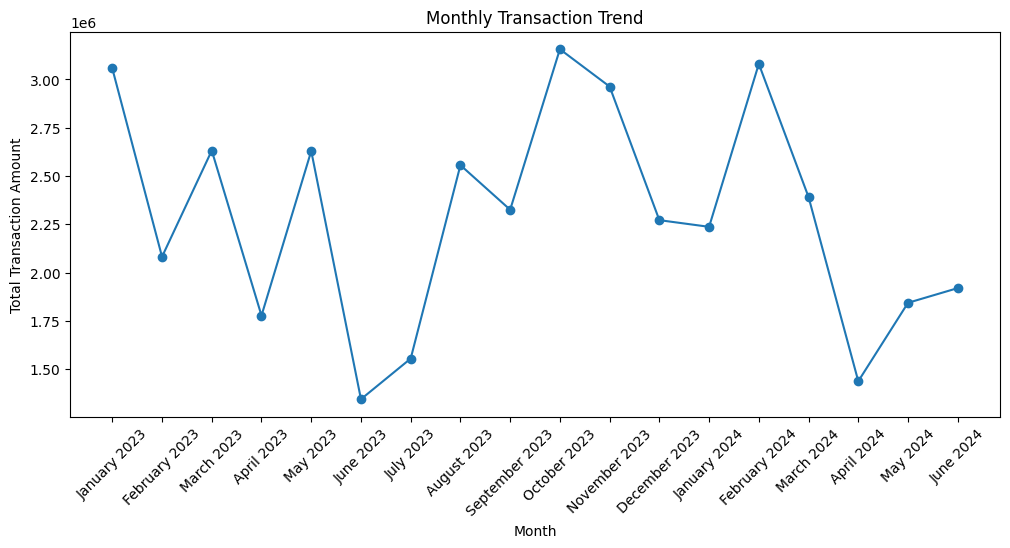

In [44]:
monthly_trend = df.groupby(
    ['Year', 'Month']
)['TransactionAmount'].sum().reset_index()

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_trend['Month'] = pd.Categorical(
    monthly_trend['Month'],
    categories=month_order,
    ordered=True
)

monthly_trend = monthly_trend.sort_values(['Year', 'Month'])

monthly_trend['Period'] = (
    monthly_trend['Month'].astype(str) + ' ' +
    monthly_trend['Year'].astype(str)
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_trend['Period'],
    monthly_trend['TransactionAmount'],
    marker='o'
)

plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.show()

##5.2 Customer Activity Distribution

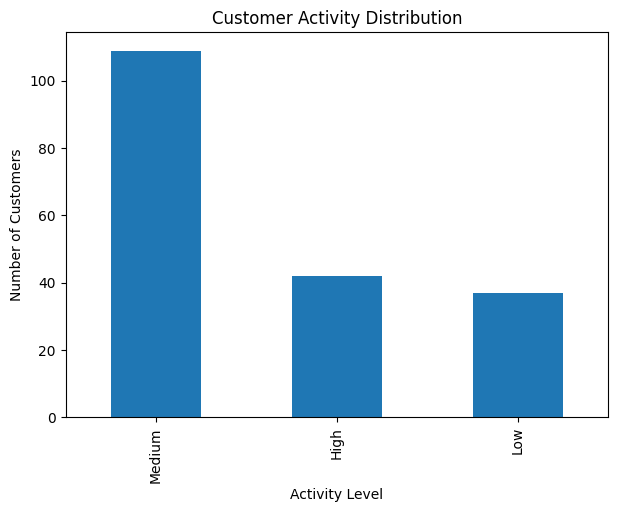

In [45]:
activity_summary.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Customer Activity Distribution')
plt.xlabel('Activity Level')
plt.ylabel('Number of Customers')
plt.show()

##5.3 Account Type Transaction Volume

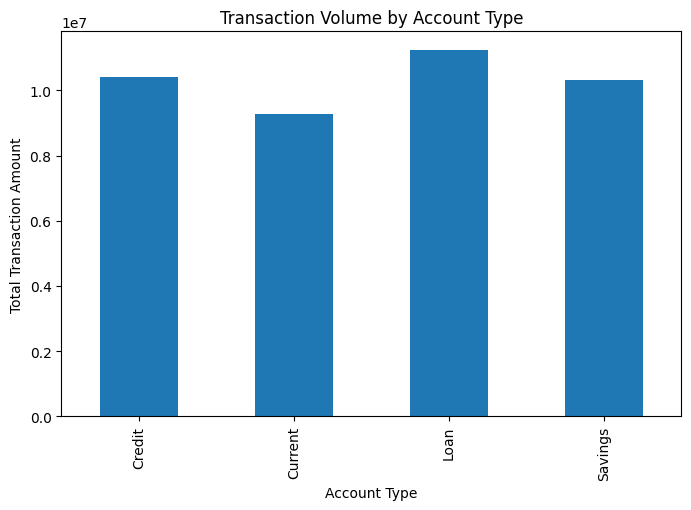

In [46]:
account_summary['sum'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Transaction Volume by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Total Transaction Amount')
plt.show()

##5.4 Business Insights



## Business Insights

* The monthly transaction trend shows noticeable fluctuations between **January 2023 and June 2024**. Transaction volume reached its highest level in **September 2023**, at approximately **₹3.18 million**, followed closely by **February 2024** at about **₹3.10 million**. These high-volume months can be used for planning staff capacity and targeted customer campaigns.

* The lowest monthly transaction volume occurred in **May 2023**, at approximately **₹1.35 million**. Another low period was **March 2024**, at approximately **₹1.43 million**. The bank can investigate whether these lower volumes are due to seasonal patterns or reduced customer engagement.

* Customer activity is dominated by the **Medium Activity** segment, with **109 customers**. There are **42 High Activity** customers and **37 Low Activity** customers. Medium-activity customers are the largest group and could be targeted with personalised offers to increase their transaction frequency.

* **High Activity customers (42)** should be prioritised for loyalty benefits, premium banking services, or cross-selling opportunities because they transact more frequently.

* **Low Activity customers (37)** may be at risk of disengagement. The bank can use reminders, digital-banking offers, or customer outreach to encourage more activity.

* Among account types, **Loan accounts** recorded the highest total transaction volume, approximately **₹11.24 million**. This indicates that loan-related accounts contribute the largest share of transaction value in the dataset.

* **Credit accounts** recorded approximately **₹10.42 million**, while **Savings accounts** recorded approximately **₹10.32 million**. These two account types also make a strong contribution to overall transaction activity.

* **Current accounts** recorded the lowest total transaction volume, approximately **₹9.27 million**. This suggests an opportunity to review current-account usage and introduce services that encourage higher transaction activity.

* Financial-risk analysis identified **21 large withdrawals**, **1 anomalous transaction**, and **1 suspicious customer**. The suspicious customer, **CUST3015**, should be prioritised for transaction review.

* Account **ACC21878** had the highest balance volatility, with a standard deviation of approximately **₹70,517.53**. Highly volatile accounts should be monitored because large balance fluctuations can indicate irregular cash movement.


# Task 6: Statistical Analysis and Hypothesis Testing

## Objective
The objective of this task is to test whether the average transaction amount differs between Deposit and Withdrawal transactions.

## Hypotheses

- **Null Hypothesis (H₀):** The average transaction amount is the same for Deposit and Withdrawal transactions.
- **Alternative Hypothesis (H₁):** The average transaction amount is different for Deposit and Withdrawal transactions.

In [47]:
from scipy.stats import ttest_ind

deposit_transactions = df[
    df['TransactionType'] == 'Deposit'
]['TransactionAmount']

withdrawal_transactions = df[
    df['TransactionType'] == 'Withdrawal'
]['TransactionAmount']

t_statistic, p_value = ttest_ind(
    deposit_transactions,
    withdrawal_transactions,
    equal_var=False
)

print("Deposit Transactions:", len(deposit_transactions))
print("Withdrawal Transactions:", len(withdrawal_transactions))
print("Average Deposit Transaction Amount:", deposit_transactions.mean())
print("Average Withdrawal Transaction Amount:", withdrawal_transactions.mean())
print("T-statistic:", t_statistic)
print("P-value:", p_value)

Deposit Transactions: 199
Withdrawal Transactions: 207
Average Deposit Transaction Amount: 52669.02430638693
Average Withdrawal Transaction Amount: 52375.09549074395
T-statistic: 0.10072926611784393
P-value: 0.9198153718472264


# Final Conclusion and Recommendations

## Project Conclusion

This project analysed 800 financial transaction records to understand transaction patterns, customer activity, account performance, and financial-risk indicators.

The dataset was clean, with no missing values or duplicate records. The analysis showed that Loan accounts had the highest total transaction volume, while Medium Activity customers formed the largest customer segment. Monthly transaction values changed considerably over time, with the highest transaction volume recorded in September 2023 at approximately ₹3.18 million.

The risk analysis identified 21 large withdrawals, 1 transaction anomaly, and 1 suspicious customer, CUST3015. Account ACC21878 showed the highest balance volatility, indicating substantial changes in its account balance over time.

The hypothesis test found no statistically significant difference between average Deposit and Withdrawal transaction amounts, as the p-value was 0.9198, which is greater than 0.05.

## Recommendations

- Monitor accounts with unusually large withdrawals and high balance volatility through automated transaction alerts.
- Review the suspicious customer, CUST3015, and the anomalous transaction for verification.
- Offer loyalty benefits or premium banking services to the 42 High Activity customers.
- Target the 37 Low Activity customers with personalised offers, reminders, and digital-banking campaigns to improve engagement.
- Use high-volume months, especially September 2023 and February 2024, for staffing, campaign planning, and customer outreach.
- Review Current account usage because it recorded the lowest total transaction volume among account types.
- Continue using anomaly-detection methods such as the IQR technique to identify unusual transaction behaviour early.

## Tools Used

- Python
- Google Colab
- Pandas
- Matplotlib
- SciPy